In [1]:
import numpy as np
import matplotlib as mpl
from scipy.optimize import minimize

# Qiskit circuit and parameter tools
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

# Qiskit operators for the Hamiltonian
from qiskit.quantum_info import SparsePauliOp
from qiskit.visualization import array_to_latex

# Modern Qiskit primitive for calculating expectation values
from qiskit.primitives import StatevectorEstimator

In [2]:
# Define the Hamiltonian
# It is a single spin particle in a magnetic field with a Z and a weaker X component
# If we used only Z or equal Z and X components, the answer would be trivial

H = SparsePauliOp.from_list([
    ("Z", 1.0),
    ("X", 0.5)
])

array_to_latex(H.to_matrix(), prefix="H = ")

<IPython.core.display.Latex object>

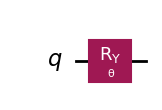

In [3]:
# Implement the ansatz
# We use the rotation gate Ry governed by theta
# This rotates the state in the x-z plane around the y axis, keeping everything real

theta = Parameter('θ')

ansatz = QuantumCircuit(1)
ansatz.ry(theta, 0)

ansatz.draw('mpl')

In [4]:
estimator = StatevectorEstimator()

def cost_function(param_values):
    """
    Evaluates the energy of the ansatz for given parameter values.
    param_values: an array of parameter values provided by the optimizer.
    """
    # Extract the single starting theta value from the array
    theta_val = param_values[0]
    
    # Bundle the circuit, observable, and parameter value into a PUB
    pub = (ansatz, H, [theta_val])
    
    # Run the estimator
    job = estimator.run([pub])
    
    # Extract the result
    result = job.result()
    energy = result[0].data.evs
    
    return float(energy)

In [ ]:
# Define a starting point (initial guess)
# Since we have 1 parameter, we provide an array with 1 initial value
initial_guess = [10.0]

# Run the optimizer
result = minimize(
    fun=cost_function,      # The objective function to minimize
    x0=initial_guess,       # The initial guess for the parameters
    method='COBYLA',        # The optimization algorithm
    options={'maxiter': 100} # Number of iterations
)

# Extract the results
optimal_theta = result.x[0]
minimum_energy = result.fun

print(f"Optimization converged: {result.success}")
print(f"Optimal Theta: {optimal_theta:.4f} radians")
print(f"Calculated Ground State Energy: {minimum_energy:.4f}")

Optimization converged: True
Optimal Theta: 9.8884 radians
Calculated Ground State Energy: -1.1180


In [ ]:
# Initial guess plays a huge role in the optimizer's prediction accuracy
# We use multi-start optimization

# Setup the Multi-Start parameters
num_starts = 50  # The number of random initial guesses to try
global_best_energy = float('inf') # Start infinitely high
global_best_theta = None
best_result_object = None

# Run the optimization loop
for i in range(num_starts):
    # Generate a random initial guess between 0 and 2*pi
    random_guess = [np.random.uniform(0, 2 * np.pi)]
    
    # Run the optimizer
    result = minimize(
        fun=cost_function,
        x0=random_guess,
        method='COBYLA',
        options={'maxiter': 100}
    )
    
    # Evaluate the global minimum
    # If this run found a lower energy than our current record, update the record
    if result.fun < global_best_energy:
        global_best_energy = result.fun
        global_best_theta = result.x[0]
        best_result_object = result
        
    # Print the results of each individual run
    print(f"Run {i+1:02d} | Start: {random_guess[0]:.4f} | Final Energy: {result.fun:.4f}")

# 4. Final output
print("\n--- Global Optimization Complete ---")
print(f"Optimization converged: {best_result_object.success}")
print(f"Global Optimal Theta: {global_best_theta:.4f} radians")
print(f"Calculated Global Ground State Energy: {global_best_energy:.4f}")

Run 01 | Start: 1.0105 | Final Energy: -1.1180
Run 02 | Start: 4.7368 | Final Energy: -1.1180
Run 03 | Start: 0.6637 | Final Energy: -1.1180
Run 04 | Start: 1.2317 | Final Energy: -1.1180
Run 05 | Start: 2.3175 | Final Energy: -1.1180
Run 06 | Start: 1.2182 | Final Energy: -1.1180
Run 07 | Start: 3.1519 | Final Energy: -1.1180
Run 08 | Start: 3.1395 | Final Energy: -1.1180
Run 09 | Start: 4.8570 | Final Energy: -1.1180
Run 10 | Start: 2.8795 | Final Energy: -1.1180
Run 11 | Start: 4.1089 | Final Energy: -1.1180
Run 12 | Start: 4.3118 | Final Energy: -1.1180
Run 13 | Start: 5.6412 | Final Energy: -1.1180
Run 14 | Start: 3.2768 | Final Energy: -1.1180
Run 15 | Start: 3.0135 | Final Energy: -1.1180
Run 16 | Start: 4.7950 | Final Energy: -1.1180
Run 17 | Start: 6.2567 | Final Energy: -1.1180
Run 18 | Start: 5.8573 | Final Energy: -1.1180
Run 19 | Start: 3.9951 | Final Energy: -1.1180
Run 20 | Start: 1.0888 | Final Energy: -1.1180
Run 21 | Start: 2.5366 | Final Energy: -1.1180
Run 22 | Star